# Smart Logistics — Data Connection, Cleaning & Validation

**Database:** PostgreSQL

The SQL scripts use PostgreSQL features such as `FILTER`, `DATE_TRUNC`, `EXTRACT`, `PERCENTILE_CONT`, and `INITCAP`.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [2]:
DB_TYPE = "PostgreSQL"
USE_DATABASE = os.getenv("USE_DATABASE", "False").lower() == "true"

DB_USER = os.getenv("POSTGRES_USER")
DB_PASSWORD = os.getenv("POSTGRES_PASSWORD")
DB_HOST = os.getenv("POSTGRES_HOST", "localhost")
DB_PORT = os.getenv("POSTGRES_PORT", "5432")
DB_NAME = os.getenv("POSTGRES_DB", "smart_logistics_db")

csv_path = "/mnt/data/smart_logistics_dataset.csv"

print("Database:", DB_TYPE)
print("Use database:", USE_DATABASE)


Database: PostgreSQL
Use database: False


In [3]:
engine = None

if USE_DATABASE:
    try:
        db_url = (
            f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}"
            f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
        )
        engine = create_engine(db_url)
        with engine.connect() as conn:
            print("PostgreSQL connection successful.")
    except Exception as e:
        print("Database connection unavailable.")
        print("Using CSV source instead.")
        engine = None
else:
    print("CSV mode selected.")


CSV mode selected.


## Load the raw dataset

In [4]:
if engine is not None:
    df_raw = pd.read_sql(text("SELECT * FROM smart_logistics"), engine)
else:
    df_raw = pd.read_csv(csv_path)

print("Raw shape:", df_raw.shape)
df_raw.head()


Raw shape: (1000, 16)


,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,NaN,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,NaN,99.2,260,0
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,NaN,71.6,270,1


In [5]:
df = df_raw.copy()

column_map = {
    "timestamp": "Timestamp",
    "asset_id": "Asset_ID",
    "latitude": "Latitude",
    "longitude": "Longitude",
    "inventory_level": "Inventory_Level",
    "shipment_status": "Shipment_Status",
    "temperature": "Temperature",
    "humidity": "Humidity",
    "traffic_status": "Traffic_Status",
    "waiting_time": "Waiting_Time",
    "user_transaction_amount": "User_Transaction_Amount",
    "user_purchase_frequency": "User_Purchase_Frequency",
    "logistics_delay_reason": "Logistics_Delay_Reason",
    "asset_utilization": "Asset_Utilization",
    "demand_forecast": "Demand_Forecast",
    "logistics_delay": "Logistics_Delay"
}

df = df.rename(columns=column_map)
print(df.columns.tolist())


['Timestamp', 'Asset_ID', 'Latitude', 'Longitude', 'Inventory_Level', 'Shipment_Status', 'Temperature', 'Humidity', 'Traffic_Status', 'Waiting_Time', 'User_Transaction_Amount', 'User_Purchase_Frequency', 'Logistics_Delay_Reason', 'Asset_Utilization', 'Demand_Forecast', 'Logistics_Delay']


## Initial profiling

In [6]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate timestamps:", df["Timestamp"].duplicated().sum())


Rows: 1000
Columns: 16
Duplicate rows: 0
Duplicate timestamps: 0


In [7]:
profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique": df.nunique(dropna=True)
})

profile


,dtype,missing,missing_pct,unique
Timestamp,object,0,0.0,1000
Asset_ID,object,0,0.0,10
Latitude,float64,0,0.0,1000
Longitude,float64,0,0.0,1000
Inventory_Level,int64,0,0.0,366
Shipment_Status,object,0,0.0,3
Temperature,float64,0,0.0,121
Humidity,float64,0,0.0,291
Traffic_Status,object,0,0.0,3
Waiting_Time,int64,0,0.0,51


In [8]:
numeric_cols = [
    "Latitude", "Longitude", "Inventory_Level", "Temperature",
    "Humidity", "Waiting_Time", "User_Transaction_Amount",
    "User_Purchase_Frequency", "Asset_Utilization",
    "Demand_Forecast", "Logistics_Delay"
]

text_cols = [
    "Asset_ID", "Shipment_Status", "Traffic_Status",
    "Logistics_Delay_Reason"
]

df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Latitude,1000.0,-1.360093,51.997183,-89.7915,-46.167975,-4.50315,44.50280,89.8701
Longitude,1000.0,0.837049,104.843618,-179.8202,-88.448075,0.67830,88.15645,179.9237
Inventory_Level,1000.0,297.915000,113.554773,100.0000,201.000000,299.00000,399.00000,500.0000
Temperature,1000.0,23.893900,3.322178,18.0000,21.200000,23.80000,26.60000,30.0000
Humidity,1000.0,65.042200,8.753765,50.0000,57.200000,65.20000,72.40000,80.0000
Waiting_Time,1000.0,35.062000,14.477768,10.0000,23.000000,35.00000,49.00000,60.0000
User_Transaction_Amount,1000.0,299.055000,117.787792,100.0000,191.750000,301.50000,405.00000,500.0000
User_Purchase_Frequency,1000.0,5.513000,2.935379,1.0000,3.000000,6.00000,8.00000,10.0000
Asset_Utilization,1000.0,79.599100,11.631153,60.0000,69.475000,79.25000,89.42500,100.0000
Demand_Forecast,1000.0,199.284000,59.920847,100.0000,144.000000,202.00000,251.25000,300.0000


## Clean missing and text values

In [9]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

print("Missing before cleaning:")
print(df.isna().sum())


Missing before cleaning:
Timestamp                    0
Asset_ID                     0
Latitude                     0
Longitude                    0
Inventory_Level              0
Shipment_Status              0
Temperature                  0
Humidity                     0
Traffic_Status               0
Waiting_Time                 0
User_Transaction_Amount      0
User_Purchase_Frequency      0
Logistics_Delay_Reason     263
Asset_Utilization            0
Demand_Forecast              0
Logistics_Delay              0
dtype: int64


In [10]:
for col in text_cols:
    df[col] = df[col].replace("", pd.NA)

df["Shipment_Status"] = df["Shipment_Status"].str.title()
df["Traffic_Status"] = df["Traffic_Status"].str.title()
df["Logistics_Delay_Reason"] = df["Logistics_Delay_Reason"].str.title()

df["Logistics_Delay_Reason"] = df["Logistics_Delay_Reason"].replace(
    {"Mechanical failure": "Mechanical Failure"}
)

print("Missing after text standardization:")
print(df.isna().sum())


Missing after text standardization:
Timestamp                    0
Asset_ID                     0
Latitude                     0
Longitude                    0
Inventory_Level              0
Shipment_Status              0
Temperature                  0
Humidity                     0
Traffic_Status               0
Waiting_Time                 0
User_Transaction_Amount      0
User_Purchase_Frequency      0
Logistics_Delay_Reason     263
Asset_Utilization            0
Demand_Forecast              0
Logistics_Delay              0
dtype: int64


In [11]:
df["Logistics_Delay_Reason"] = df["Logistics_Delay_Reason"].fillna(
    "No Reason Recorded"
)

critical_cols = [
    "Timestamp", "Asset_ID", "Latitude", "Longitude",
    "Inventory_Level", "Shipment_Status", "Temperature",
    "Humidity", "Traffic_Status", "Waiting_Time",
    "User_Transaction_Amount", "User_Purchase_Frequency",
    "Asset_Utilization", "Demand_Forecast", "Logistics_Delay"
]

before_null_drop = len(df)
df = df.dropna(subset=critical_cols).copy()
null_rows_removed = before_null_drop - len(df)

print("Rows removed for critical nulls:", null_rows_removed)
print("Remaining nulls:", int(df.isna().sum().sum()))


Rows removed for critical nulls: 0
Remaining nulls: 0


## Remove duplicate records

In [12]:
duplicate_rows = df.duplicated().sum()
duplicate_keys = df.duplicated(
    subset=["Timestamp", "Asset_ID"],
    keep=False
).sum()

print("Duplicate full rows:", duplicate_rows)
print("Duplicate Timestamp + Asset_ID rows:", duplicate_keys)


Duplicate full rows: 0
Duplicate Timestamp + Asset_ID rows: 0


In [13]:
before_duplicates = len(df)

df = df.drop_duplicates().copy()
df = df.drop_duplicates(
    subset=["Timestamp", "Asset_ID"],
    keep="first"
).copy()

duplicate_rows_removed = before_duplicates - len(df)

print("Duplicate rows removed:", duplicate_rows_removed)
print("Remaining duplicate rows:", df.duplicated().sum())
print("Remaining duplicate Timestamp + Asset_ID:", df.duplicated(
    subset=["Timestamp", "Asset_ID"]
).sum())


Duplicate rows removed: 0
Remaining duplicate rows: 0
Remaining duplicate Timestamp + Asset_ID: 0


## Validate categories

In [14]:
expected_status = {"Delayed", "Delivered", "In Transit"}
expected_traffic = {"Clear", "Detour", "Heavy"}
expected_reasons = {
    "Weather", "Traffic", "Mechanical Failure", "No Reason Recorded"
}

invalid_status = sorted(set(df["Shipment_Status"].dropna()) - expected_status)
invalid_traffic = sorted(set(df["Traffic_Status"].dropna()) - expected_traffic)
invalid_reasons = sorted(set(df["Logistics_Delay_Reason"].dropna()) - expected_reasons)

print("Invalid shipment status:", invalid_status)
print("Invalid traffic status:", invalid_traffic)
print("Invalid delay reason:", invalid_reasons)


Invalid shipment status: []
Invalid traffic status: []
Invalid delay reason: []


In [15]:
print("Shipment status counts")
print(df["Shipment_Status"].value_counts())

print("\nTraffic status counts")
print(df["Traffic_Status"].value_counts())

print("\nDelay reason counts")
print(df["Logistics_Delay_Reason"].value_counts())


Shipment status counts
Shipment_Status
Delayed       350
Delivered     338
In Transit    312
Name: count, dtype: Int64

Traffic status counts
Traffic_Status
Detour    345
Clear     328
Heavy     327
Name: count, dtype: Int64

Delay reason counts
Logistics_Delay_Reason
Weather               267
No Reason Recorded    263
Traffic               236
Mechanical Failure    234
Name: count, dtype: Int64


## Validate numeric ranges

In [16]:
range_checks = {
    "Latitude": (-90, 90),
    "Longitude": (-180, 180),
    "Inventory_Level": (0, np.inf),
    "Temperature": (-50, 60),
    "Humidity": (0, 100),
    "Waiting_Time": (0, np.inf),
    "User_Transaction_Amount": (0, np.inf),
    "User_Purchase_Frequency": (0, np.inf),
    "Asset_Utilization": (0, 100),
    "Demand_Forecast": (0, np.inf),
    "Logistics_Delay": (0, 1)
}

range_results = []

for col, limits in range_checks.items():
    low, high = limits
    bad = ((df[col] < low) | (df[col] > high)).sum()
    range_results.append([col, low, high, int(bad)])

range_results = pd.DataFrame(
    range_results,
    columns=["Column", "Min Allowed", "Max Allowed", "Invalid Rows"]
)

range_results


,Column,Min Allowed,Max Allowed,Invalid Rows
0,Latitude,-90,90.0,0
1,Longitude,-180,180.0,0
2,Inventory_Level,0,inf,0
3,Temperature,-50,60.0,0
4,Humidity,0,100.0,0
5,Waiting_Time,0,inf,0
6,User_Transaction_Amount,0,inf,0
7,User_Purchase_Frequency,0,inf,0
8,Asset_Utilization,0,100.0,0
9,Demand_Forecast,0,inf,0


In [17]:
invalid_numeric_rows = pd.Series(False, index=df.index)

for col, limits in range_checks.items():
    low, high = limits
    invalid_numeric_rows = invalid_numeric_rows | (df[col] < low) | (df[col] > high)

print("Rows with invalid numeric values:", int(invalid_numeric_rows.sum()))


Rows with invalid numeric values: 0


In [18]:
before_range_clean = len(df)
df = df.loc[~invalid_numeric_rows].copy()
range_rows_removed = before_range_clean - len(df)

print("Rows removed for invalid ranges:", range_rows_removed)
print("Rows remaining:", len(df))


Rows removed for invalid ranges: 0
Rows remaining: 1000


## Detect and remove statistical outliers

In [19]:
outlier_cols = [
    "Inventory_Level",
    "Waiting_Time",
    "User_Transaction_Amount",
    "User_Purchase_Frequency",
    "Asset_Utilization",
    "Demand_Forecast"
]

outlier_summary = []

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, q1, q3, iqr, lower, upper, int(count)])

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=["Column", "Q1", "Q3", "IQR", "Lower Bound", "Upper Bound", "Outliers"]
)

outlier_summary


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers
0,Inventory_Level,201.000,399.000,198.00,-96.000,696.000,0
1,Waiting_Time,23.000,49.000,26.00,-16.000,88.000,0
2,User_Transaction_Amount,191.750,405.000,213.25,-128.125,724.875,0
3,User_Purchase_Frequency,3.000,8.000,5.00,-4.500,15.500,0
4,Asset_Utilization,69.475,89.425,19.95,39.550,119.350,0
5,Demand_Forecast,144.000,251.250,107.25,-16.875,412.125,0


In [20]:
outlier_mask = pd.Series(False, index=df.index)

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_mask = outlier_mask | (df[col] < lower) | (df[col] > upper)

print("Total rows flagged by IQR:", int(outlier_mask.sum()))


Total rows flagged by IQR: 0


In [21]:
before_outlier_clean = len(df)
df = df.loc[~outlier_mask].copy()
outlier_rows_removed = before_outlier_clean - len(df)

print("Rows removed as statistical outliers:", outlier_rows_removed)
print("Rows remaining:", len(df))


Rows removed as statistical outliers: 0
Rows remaining: 1000


/tmp/ipykernel_1849/1330709125.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


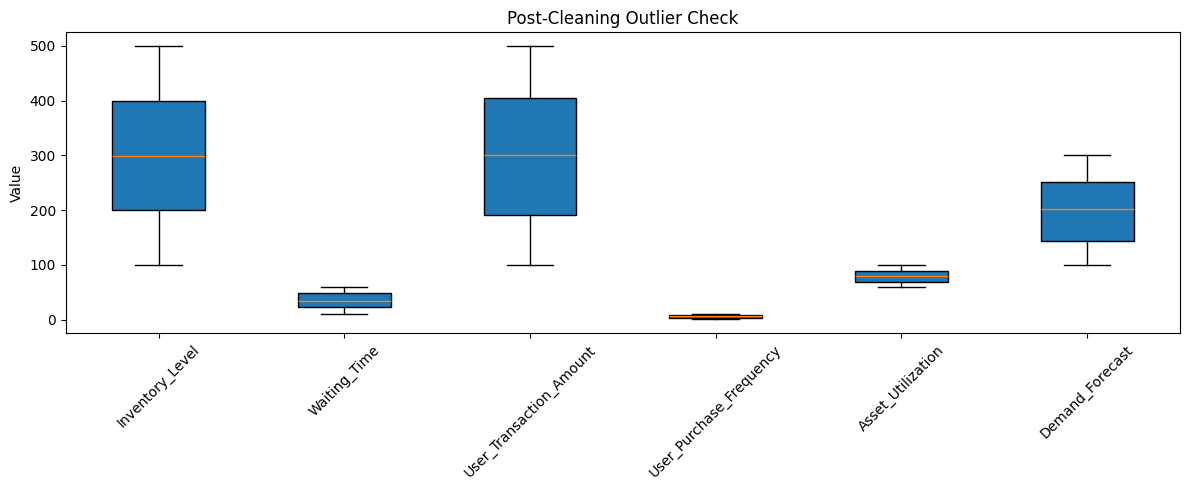

In [22]:
plt.figure(figsize=(12, 5))
plt.boxplot(
    [df[col] for col in outlier_cols],
    labels=outlier_cols,
    patch_artist=True
)
plt.xticks(rotation=45)
plt.title("Post-Cleaning Outlier Check")
plt.ylabel("Value")
plt.tight_layout()
plt.show()


## Validate dates and business logic

In [23]:
date_checks = pd.Series({
    "Invalid timestamps": df["Timestamp"].isna().sum(),
    "Future timestamps": (df["Timestamp"] > pd.Timestamp.now()).sum(),
    "Minimum timestamp": df["Timestamp"].min(),
    "Maximum timestamp": df["Timestamp"].max()
})

date_checks


Invalid timestamps                      0
Future timestamps                       0
Minimum timestamp     2024-01-01 11:37:57
Maximum timestamp     2024-12-30 20:21:58
dtype: object

In [24]:
delay_flag_invalid = (~df["Logistics_Delay"].isin([0, 1])).sum()
delay_flag_missing = df["Logistics_Delay"].isna().sum()

print("Invalid delay flags:", delay_flag_invalid)
print("Missing delay flags:", delay_flag_missing)


Invalid delay flags: 0
Missing delay flags: 0


In [25]:
status_delay_check = pd.crosstab(
    df["Shipment_Status"],
    df["Logistics_Delay"]
)

status_delay_check


Logistics_Delay,0,1
Shipment_Status,,
Delayed,0,350
Delivered,220,118
In Transit,214,98


In [26]:
reason_delay_check = pd.crosstab(
    df["Logistics_Delay_Reason"],
    df["Logistics_Delay"]
)

reason_delay_check


Logistics_Delay,0,1
Logistics_Delay_Reason,,
Mechanical Failure,101,133
No Reason Recorded,116,147
Traffic,101,135
Weather,116,151


In [27]:
inventory_gap = df["Demand_Forecast"] - df["Inventory_Level"]

logic_checks = pd.DataFrame({
    "Check": [
        "Inventory values non-negative",
        "Demand forecast values non-negative",
        "Asset utilization within 0-100",
        "Humidity within 0-100",
        "Latitude within -90 to 90",
        "Longitude within -180 to 180",
        "Delay flag is binary",
        "Purchase frequency is positive",
        "Transaction amount is non-negative"
    ],
    "Invalid Rows": [
        (df["Inventory_Level"] < 0).sum(),
        (df["Demand_Forecast"] < 0).sum(),
        ((df["Asset_Utilization"] < 0) | (df["Asset_Utilization"] > 100)).sum(),
        ((df["Humidity"] < 0) | (df["Humidity"] > 100)).sum(),
        ((df["Latitude"] < -90) | (df["Latitude"] > 90)).sum(),
        ((df["Longitude"] < -180) | (df["Longitude"] > 180)).sum(),
        (~df["Logistics_Delay"].isin([0, 1])).sum(),
        (df["User_Purchase_Frequency"] <= 0).sum(),
        (df["User_Transaction_Amount"] < 0).sum()
    ]
})

logic_checks


,Check,Invalid Rows
0,Inventory values non-negative,0
1,Demand forecast values non-negative,0
2,Asset utilization within 0-100,0
3,Humidity within 0-100,0
4,Latitude within -90 to 90,0
5,Longitude within -180 to 180,0
6,Delay flag is binary,0
7,Purchase frequency is positive,0
8,Transaction amount is non-negative,0


In [28]:
df["Inventory_Status"] = np.where(
    df["Demand_Forecast"] > df["Inventory_Level"],
    "Restock Needed",
    "Sufficient Stock"
)

df["Shift"] = np.where(
    df["Timestamp"].dt.hour.between(6, 17),
    "Day Shift",
    "Night Shift"
)

df["Delay_Status"] = np.where(
    df["Logistics_Delay"] == 1,
    "Delayed",
    "Not Delayed"
)

print(df[["Inventory_Status", "Shift", "Delay_Status"]].head())


   Inventory_Status        Shift Delay_Status
0  Sufficient Stock  Night Shift      Delayed
1  Sufficient Stock    Day Shift      Delayed
2    Restock Needed  Night Shift  Not Delayed
3  Sufficient Stock  Night Shift      Delayed
4  Sufficient Stock    Day Shift      Delayed


## Check business categories after cleaning

## Final validation

In [29]:
final_nulls = int(df.isna().sum().sum())
final_duplicates = int(df.duplicated().sum())
final_duplicate_keys = int(
    df.duplicated(subset=["Timestamp", "Asset_ID"]).sum()
)

print("Final null cells:", final_nulls)
print("Final duplicate rows:", final_duplicates)
print("Final duplicate Timestamp + Asset_ID:", final_duplicate_keys)


Final null cells: 0
Final duplicate rows: 0
Final duplicate Timestamp + Asset_ID: 0


In [30]:
validation_summary = pd.DataFrame({
    "Validation": [
        "Critical nulls",
        "Duplicate rows",
        "Duplicate Timestamp + Asset_ID",
        "Invalid shipment categories",
        "Invalid traffic categories",
        "Invalid delay reasons",
        "Invalid numeric ranges",
        "IQR outlier rows removed",
        "Rows removed for nulls",
        "Rows removed for duplicates",
        "Rows removed for ranges"
    ],
    "Result": [
        final_nulls,
        final_duplicates,
        final_duplicate_keys,
        len(invalid_status),
        len(invalid_traffic),
        len(invalid_reasons),
        int(invalid_numeric_rows.sum()),
        outlier_rows_removed,
        null_rows_removed,
        duplicate_rows_removed,
        range_rows_removed
    ]
})

validation_summary


,Validation,Result
0,Critical nulls,0
1,Duplicate rows,0
2,Duplicate Timestamp + Asset_ID,0
3,Invalid shipment categories,0
4,Invalid traffic categories,0
5,Invalid delay reasons,0
6,Invalid numeric ranges,0
7,IQR outlier rows removed,0
8,Rows removed for nulls,0
9,Rows removed for duplicates,0


## Save cleaned data

In [31]:
output_path = "/mnt/data/smart_logistics_cleaned.csv"
df.to_csv(output_path, index=False)

print("Cleaned rows:", len(df))
print("Saved:", output_path)


Cleaned rows: 1000
Saved: /mnt/data/smart_logistics_cleaned.csv


In [32]:
print("Cleaning and validation complete.")
print("Final shape:", df.shape)
print("Final revenue:", round(df["User_Transaction_Amount"].sum(), 2))
print("Final delays:", int(df["Logistics_Delay"].sum()))
print("Final assets:", df["Asset_ID"].nunique())


Cleaning and validation complete.
Final shape: (1000, 19)
Final revenue: 299055
Final delays: 566
Final assets: 10
